In [2]:
import kagglehub
path = kagglehub.dataset_download('gti-upm/leapgestrecog')
print(path)

100%|██████████| 2.13G/2.13G [01:14<00:00, 30.5MB/s]

Extracting files...


/root/.cache/kagglehub/datasets/gti-upm/leapgestrecog/versions/1


Images: 20000 | Classes: [np.str_('01_palm'), np.str_('02_l'), np.str_('03_fist'), np.str_('04_fist_moved'), np.str_('05_thumb'), np.str_('06_index'), np.str_('07_ok'), np.str_('08_palm_moved'), np.str_('09_c'), np.str_('10_down')]


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
450/450 ━━━━━━━━━━━━━━━━━━━━ 84s 181ms/step - accuracy: 0.8469 - loss: 0.4532 - val_accuracy: 0.9969 - val_loss: 0.0129
Epoch 2/10
450/450 ━━━━━━━━━━━━━━━━━━━━ 86s 192ms/step - accuracy: 0.9808 - loss: 0.0628 - val_accuracy: 0.9969 - val_loss: 0.0059
Epoch 3/10
450/450 ━━━━━━━━━━━━━━━━━━━━ 96s 213ms/step - accuracy: 0.9861 - loss: 0.0393 - val_accuracy: 0.9994 - val_loss: 0.0027
Epoch 4/10
450/450 ━━━━━━━━━━━━━━━━━━━━ 84s 188ms/step - accuracy: 0.9901 - loss: 0.0294 - val_accuracy: 0.9981 - val_loss: 0.0044
Epoch 5/10
450/450 ━━━━━━━━━━━━━━━━━━━━ 137s 177ms/step - accuracy: 0.9933 - loss: 0.0204 - val_accuracy: 1.0000 - val_loss: 0.0014
Epoch 6/10
450/450 ━━━━━━━━━━━━━━━━━━━━ 84s 182ms/step - accuracy: 0.9929 - loss: 0.0188 - val_accuracy: 0.9994 - val_loss: 0.0010
Epoch 7/10
450/450 ━━━━━━━━━━━━━━━━━━━━ 77s 172ms/step - accuracy: 0.9929 - loss: 0.0197 - val_accuracy: 0.9987 - val_loss: 0.0013
Epoch 8/10
450/450 ━━━━━━━━━━━━━━━━━━━━ 77s 172ms/step - accuracy: 0.9942 - loss: 

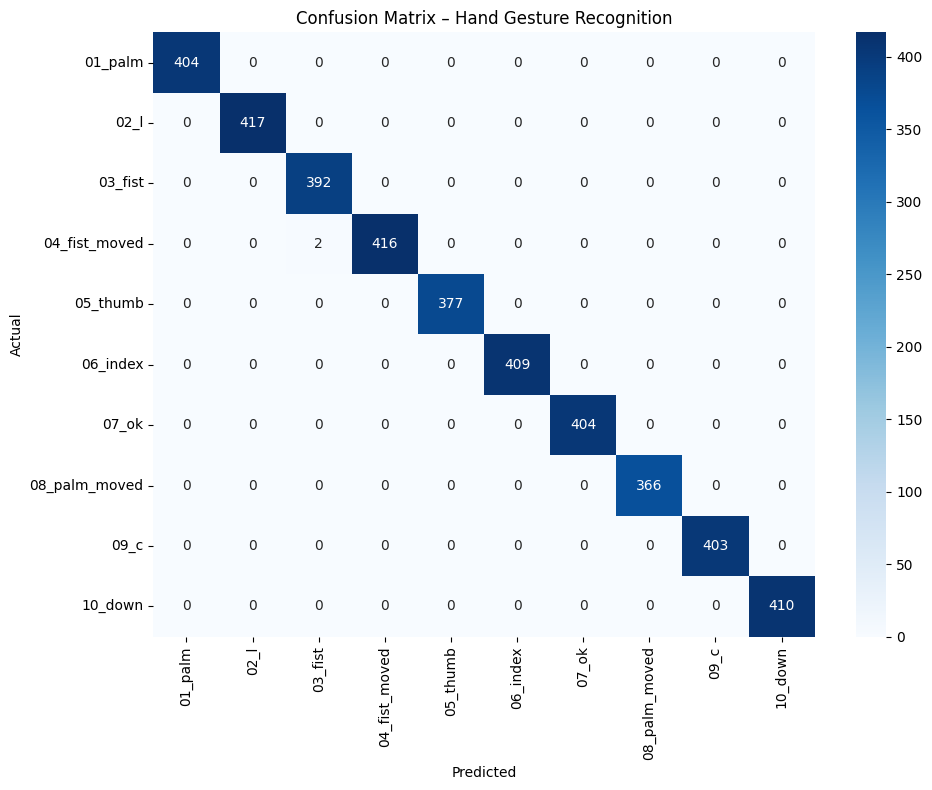

In [5]:
# SKILLCRAFT TECHNOLOGY – TASK 04
# Hand Gesture Recognition using CNN
# Joshua Pinto
# Dataset: LeapGestRecog (Kaggle)

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical
import seaborn as sns

IMG_SIZE = 64
MAX_PER_CLASS = 200
dataset_dir = '/root/.cache/kagglehub/datasets/gti-upm/leapgestrecog/versions/1/leapGestRecog'

# Load Data
data, labels = [], []

for subject in os.listdir(dataset_dir):
    subject_path = os.path.join(dataset_dir, subject)
    if not os.path.isdir(subject_path): continue
    for gesture in os.listdir(subject_path):
        gesture_path = os.path.join(subject_path, gesture)
        if not os.path.isdir(gesture_path): continue
        count = 0
        for img_name in os.listdir(gesture_path):
            if count >= MAX_PER_CLASS: break
            img = cv2.imread(os.path.join(gesture_path, img_name))
            if img is None: continue
            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
            data.append(img)
            labels.append(gesture)
            count += 1

X = np.array(data) / 255.0
le = LabelEncoder()
y = to_categorical(le.fit_transform(labels))
num_classes = y.shape[1]
print(f"Images: {X.shape[0]} | Classes: {list(le.classes_)}")

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Model
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    MaxPooling2D(2,2),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train
history = model.fit(X_train, y_train, epochs=10, batch_size=32, validation_split=0.1)

# Evaluate
loss, acc = model.evaluate(X_test, y_test)
print(f"\nTest Accuracy: {acc*100:.2f}%")

y_pred = np.argmax(model.predict(X_test), axis=1)
y_true = np.argmax(y_test, axis=1)
print(classification_report(y_true, y_pred, target_names=le.classes_))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix – Hand Gesture Recognition')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()